# Testing the Potential class framework

`22/09/2026`

Systematic parameter sweeps of the class implementations. For every model
(`MorseSoftCoulomb` and `SoftCoulomb`), for a grid of softening parameters
$\alpha$ and bound energies $E$, we validate the same five physical
invariants:

   (i)   **turning points**: $V(r_m) = V(r_M) = E$;
   (ii)  **momentum**: real & non-negative inside the well, `0` at the return
         points, `NaN` in the forbidden region;
   (iii) **phase space**: every $(r, p)$ on the closed orbit reproduces the
         input energy;
   (iv)  **angular frequency**: $\omega$ from `angular_frequency()` must equal
         $\mathrm{d}E/\mathrm{d}J$, computed by finite-differencing the action —
         two completely independent numerical routes;
   (v)   **canonical angle**: $\theta(r_m) = 0$ and $\theta(r_M) = \pi$,
         monotonically spanning $[0, \pi]$ over one half-period.

None of these tests rely on the old scripted routines — everything is checked
against internal consistency of the class API itself.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

from emerald.potentials import MorseSoftCoulomb, SoftCoulomb


## 1. Validation infrastructure

Below are the constants that define the sweep and the five check functions.
Every check `assert`s on failure, so a broken quantity stops the sweep with a
clear message.


In [5]:
N_Q = 1500                       # Gauss-Legendre quadrature points for all checks
ALPHAS = np.array([0.25, 0.5, 1.0, 2.0])   # softening-parameter sweep
fE = np.linspace(0.02, 0.98, 20)           # fraction of well depth: E = -f * well_depth

TOL_TP  = 1.e-10    # relative error allowed for V(turning) == E
TOL_PS  = 1.e-10    # relative roundtrip energy error from the phase-space orbit
TOL_OMG = 5.e-3     # relative agreement between omega and dE/dJ
TOL_TH  = 1.e-6     # absolute error allowed on angle endpoints (0 and pi)


def turning_points_check(V, E):
    # (i) Turning points are real, ordered and satisfy V(rm) = V(rM) = E.
    rm, rM = V.turning_points(E)
    assert np.isfinite(rm) and np.isfinite(rM), f"turning points not finite at E={E}"
    assert rm < rM, f"turning points not ordered at E={E}: {rm} >= {rM}"
    e_rm = abs(V.value(rm) - E) / max(1.0, abs(E))
    e_rM = abs(V.value(rM) - E) / max(1.0, abs(E))
    assert max(e_rm, e_rM) < TOL_TP, f"V(turning) != E at E={E}: rel {e_rm:.2e}, {e_rM:.2e}"
    return max(e_rm, e_rM)


def momentum_check(V, E):
    # (ii) Momentum is real inside the well, ~0 at the turning points, NaN outside.
    rm, rM = V.turning_points(E)
    r_in = np.linspace(rm + 1.e-9, rM - 1.e-9, 300)
    p = V.momentum(E, r_in)
    assert np.all(np.isfinite(p)), f"momentum not finite inside the well at E={E}"
    assert p.min() >= -1.e-9 and p.max() > 0, f"momentum not physical inside the well at E={E}"
    pend = V.momentum(E, np.array([rm, rM]))
    assert np.allclose(pend, 0.0, atol=1.e-6), f"momentum not zero at the turning points at E={E}"
    pout = V.momentum(E, np.array([rm - 1.e-3, rM + 1.e-3]))
    assert not np.any(np.isfinite(pout)), f"momentum not NaN in the forbidden region at E={E}"


def phase_space_check(V, E):
    # (iii) Phase-space orbit is closed and conserves energy at every point.
    r, p = V.phase_space(E, N=800, r1=-10, r2=10)
    E_rec = p**2 / 2 + V.value(r)
    fin = np.isfinite(E_rec)
    err = np.max(np.abs(E_rec[fin] - E)) / max(1.0, abs(E))
    assert np.allclose(p[0], 0.0, atol=1.e-8) and np.allclose(p[-1], 0.0, atol=1.e-8), \
        f"phase-space orbit not closed at E={E}"
    assert err < TOL_PS, f"energy not conserved on phase-space orbit at E={E}: rel {err:.2e}"
    return err


def omega_fd_check(V, E, dE_rel=1.e-3):
    # (iv) omega from angular_frequency() == dE/dJ from a 4th-order central difference of action.
    step = dE_rel * max(1.0, abs(E))
    Jm2, Jm1, Jp1, Jp2 = (V.action(e, N=N_Q) for e in (E - 2*step, E - step, E + step, E + 2*step))
    dJdE = (Jm2 - 8*Jm1 + 8*Jp1 - Jp2) / (12*step)
    omg_fd = 1.0 / dJdE
    omg = V.angular_frequency(E, N=N_Q)
    rel = abs(omg - omg_fd) / omg
    assert rel < TOL_OMG, f"omega vs dE/dJ mismatch at E={E}: class={omg:.8f}, fd={omg_fd:.8f}, rel={rel:.2e}"
    return rel


def angle_endpoints_check(V, E):
    # (v) Canonical angle: theta(rm) = 0 and theta(rM) = pi.
    rm, rM = V.turning_points(E)
    th_m = float(V.angle(E, rm, N=N_Q))
    th_M = float(V.angle(E, rM, N=N_Q))
    assert th_m == 0.0, f"angle(rm) = {th_m} != 0 at E={E}"
    assert abs(th_M - np.pi) < TOL_TH, f"angle(rM) = {th_M} != pi at E={E}"
    return abs(th_M - np.pi)


def angle_curve(V, E, r_s, N=500):
    # Angle along a radial grid; also flags whether it is monotonically increasing.
    th = V.angle(E, r_s, N=N)
    return th, bool(np.all(np.diff(th) >= -1.e-9))


def run_sweep(factory):
    # Run all five checks over every (alpha, E) and collect worst-case errors.
    stats = {'turning': 0., 'phase': 0., 'omega': 0., 'theta': 0.}
    npnts = 0
    for alpha in ALPHAS:
        V = factory(alpha)
        for f in fE:
            E = -f * V.well_depth
            npnts += 1
            stats['turning'] = max(stats['turning'], turning_points_check(V, E))
            momentum_check(V, E)
            stats['phase'] = max(stats['phase'], phase_space_check(V, E))
            stats['omega'] = max(stats['omega'], omega_fd_check(V, E))
            stats['theta'] = max(stats['theta'], angle_endpoints_check(V, E))
    stats['points'] = npnts
    return stats


## 2. MsC potential: systematic sweep

Runs every check across $\alpha \in \{0.25, 0.5, 1, 2\}$ and 20 energies spread
between 2% and 98% of the well depth (80 states total). The strictest of these
is the $\omega$ vs $\mathrm{d}E/\mathrm{d}J$ cross-check; the action and the
angular frequency are computed by unrelated quadratures, so agreement here
validates both.


In [6]:
msc_stats = run_sweep(MorseSoftCoulomb)
print(f"MsC sweep: {msc_stats.pop('points')} states checked, no assertions raised.")
print("worst-case (relative) errors across the whole sweep:")
for k, v in msc_stats.items():
    print(f"   {k:<8s} {v:.3e}")


MsC sweep: 80 states checked, no assertions raised.
worst-case (relative) errors across the whole sweep:
   turning  2.554e-15
   phase    2.554e-15
   omega    2.048e-04
   theta    4.441e-16


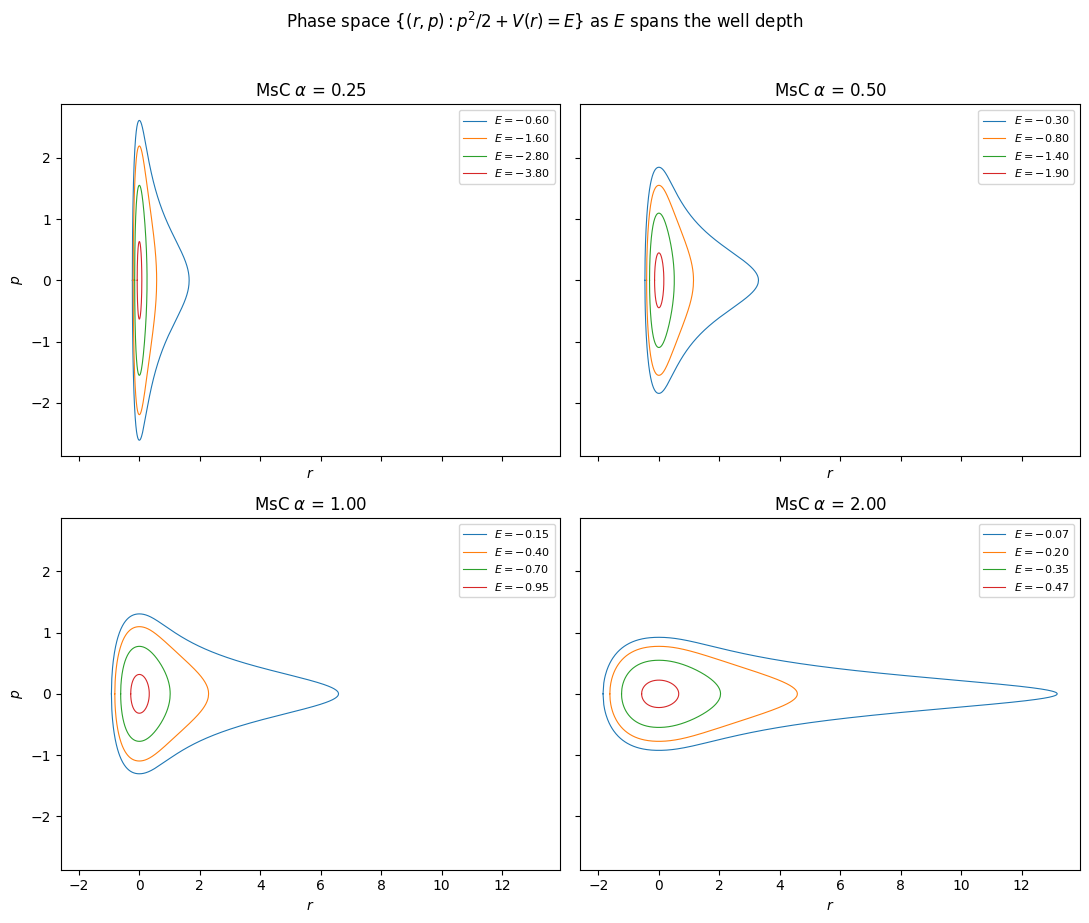

In [7]:
# Phase-space portraits: one closed orbit per energy, several energies per alpha
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, alpha in zip(axes.ravel(), ALPHAS):
    V = MorseSoftCoulomb(alpha)
    for f in [0.15, 0.4, 0.7, 0.95]:
        E = -f * V.well_depth
        r, p = V.phase_space(E, N=600, r1=-4, r2=6)
        ax.plot(r, p, lw=0.8, label=f"$E = {E:.2f}$")
    ax.set_title(f"MsC $\\alpha$ = {alpha:.2f}")
    ax.set_xlabel("$r$")
    ax.legend(fontsize=8)
axes[0, 0].set_ylabel("$p$")
axes[1, 0].set_ylabel("$p$")
fig.suptitle("Phase space $\\{(r,p): p^2/2 + V(r) = E\\}$ as $E$ spans the well depth", y=1.02)
plt.tight_layout()
plt.show()


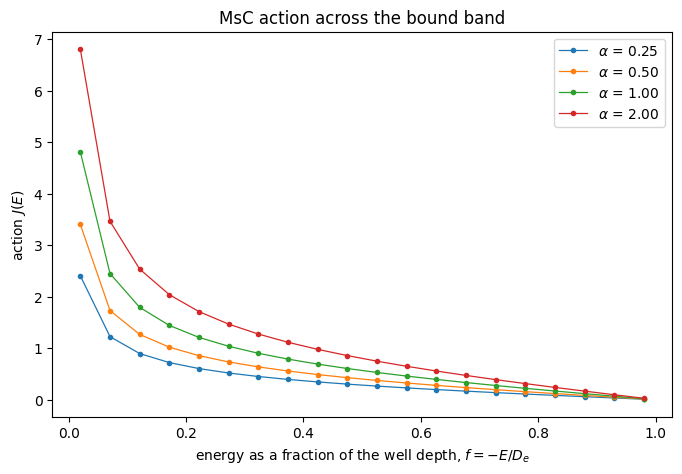

In [8]:
# Action as a function of energy, one curve per alpha
fig, ax = plt.subplots(figsize=(8, 5))
for alpha in ALPHAS:
    V = MorseSoftCoulomb(alpha)
    Js = np.array([V.action(-f * V.well_depth, N=N_Q) for f in fE])
    ax.plot(fE, Js, marker="o", ms=3, lw=0.9, label=f"$\\alpha$ = {alpha:.2f}")
ax.set_xlabel("energy as a fraction of the well depth, $f = -E/D_e$")
ax.set_ylabel("action $J(E)$")
ax.set_title("MsC action across the bound band")
ax.legend()
plt.show()


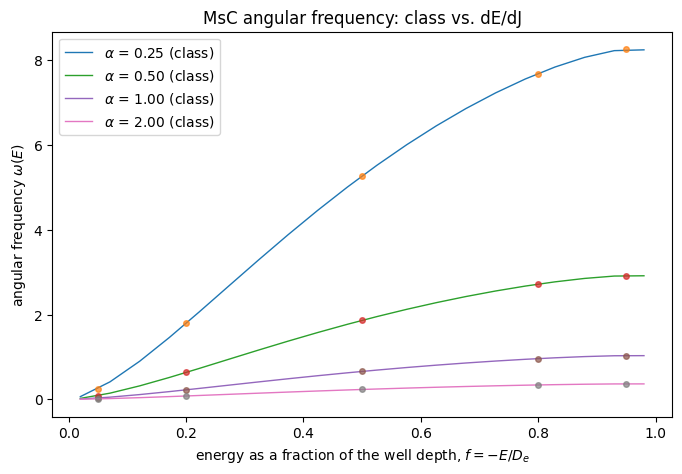

In [9]:
# Angular frequency: class curve vs. dE/dJ computed by a finite difference of action
def omega_fd(V, E, dE_rel=1.e-3):
    # omega == dE/dJ via 4th-order central difference of the action
    step = dE_rel * max(1.0, abs(E))
    Jm2, Jm1, Jp1, Jp2 = (V.action(e, N=N_Q) for e in (E - 2*step, E - step, E + step, E + 2*step))
    dJdE = (Jm2 - 8*Jm1 + 8*Jp1 - Jp2) / (12*step)
    return 1.0 / dJdE

fig, ax = plt.subplots(figsize=(8, 5))
f_c = [0.05, 0.2, 0.5, 0.8, 0.95]
for alpha in ALPHAS:
    V = MorseSoftCoulomb(alpha)
    omg = np.array([V.angular_frequency(-f * V.well_depth, N=N_Q) for f in fE])
    ax.plot(fE, omg, lw=1.0, label=f"$\\alpha$ = {alpha:.2f} (class)")
    ax.plot(f_c, [omega_fd(V, -f * V.well_depth) for f in f_c], "o", ms=4, alpha=0.7)
ax.set_xlabel("energy as a fraction of the well depth, $f = -E/D_e$")
ax.set_ylabel("angular frequency $\\omega(E)$")
ax.set_title("MsC angular frequency: class vs. dE/dJ")
ax.legend()
plt.show()


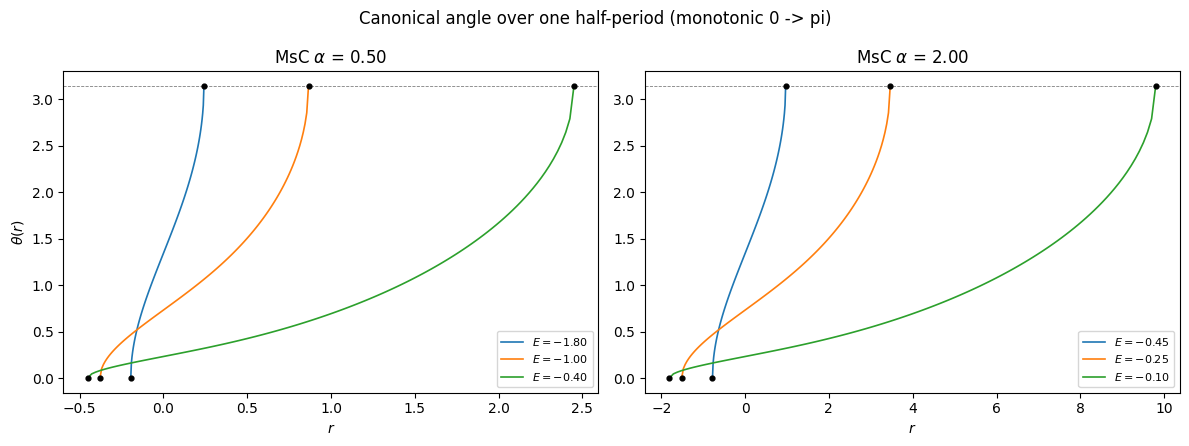

In [10]:
# Canonical angle along r for several energies: theta(rm)=0, theta(rM)=pi, monotonic
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, alpha in zip(axes, [0.5, 2.0]):
    V = MorseSoftCoulomb(alpha)
    for E in [0.9, 0.5, 0.2] and [_ for _ in (V.well_depth * -np.array([0.9, 0.5, 0.2]))]:
        E = float(E)
        rm, rM = V.turning_points(E)
        r_s = np.linspace(rm, rM, 120)
        th, mono = angle_curve(V, E, r_s)
        assert mono, f"angle not monotonic for alpha={alpha}, E={E}"
        ax.plot(r_s, th, lw=1.2, label=f"$E = {E:.2f}$")
        tp = V.turning_points(E)
        ax.scatter([tp[0].item(), tp[1].item()], [0.0, np.pi], color="k", s=12, zorder=3)
    ax.axhline(np.pi, color="grey", lw=0.6, ls="--")
    ax.set_title(f"MsC $\\alpha$ = {alpha:.2f}")
    ax.set_xlabel("$r$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("$\\theta(r)$")
fig.suptitle("Canonical angle over one half-period (monotonic 0 -> pi)")
plt.tight_layout()
plt.show()


## 3. sC potential: systematic sweep

The soft-Coulomb potential is even, so it exercises the *symmetric* code paths
in the base class (`_check_symmetry`, the folded action integral, the mirrored
phase-space orbit, and the angle on $[-r_M, r_M]$). Any symmetry bug shows up
here immediately.


In [11]:
sc_stats = run_sweep(SoftCoulomb)
print(f"sC sweep: {sc_stats.pop('points')} states checked, no assertions raised.")
print("worst-case (relative) errors across the whole sweep:")
for k, v in sc_stats.items():
    print(f"   {k:<8s} {v:.3e}")


sC sweep: 80 states checked, no assertions raised.
worst-case (relative) errors across the whole sweep:
   turning  1.718e-16
   phase    6.106e-16
   omega    2.053e-04
   theta    4.441e-16


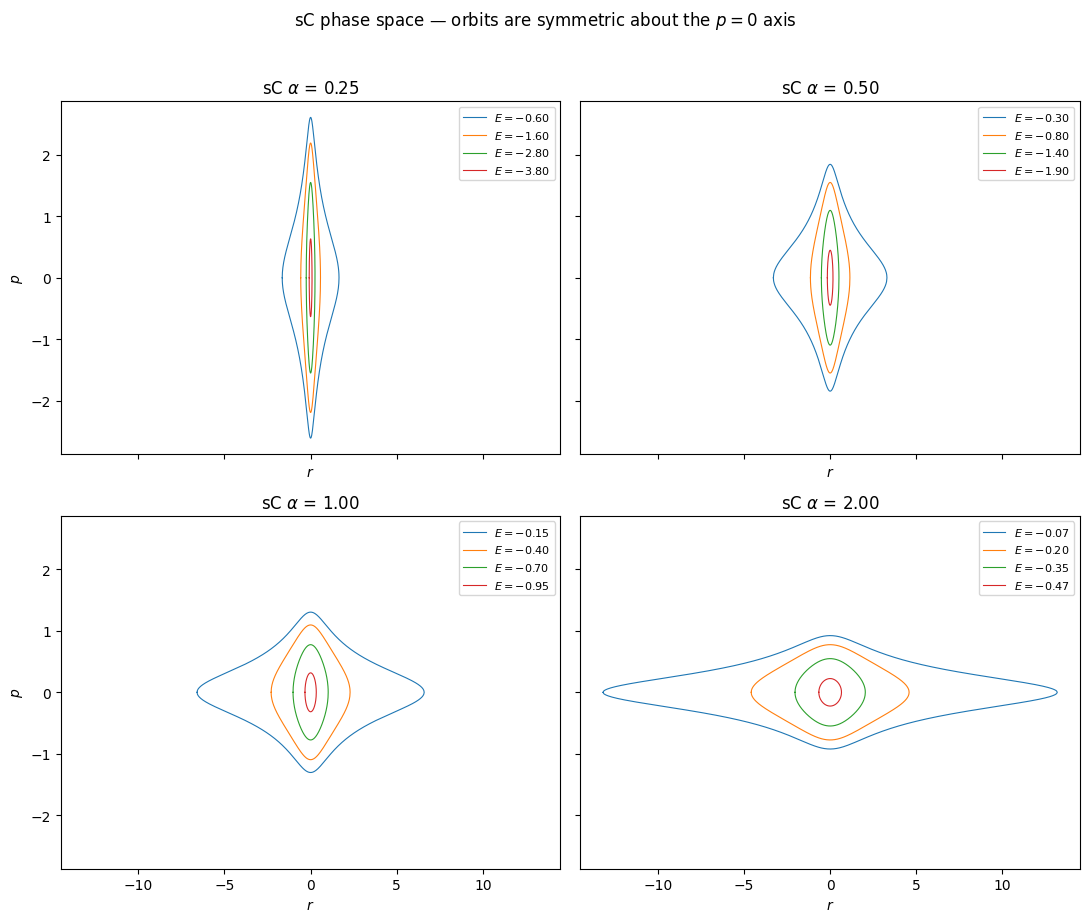

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
for ax, alpha in zip(axes.ravel(), ALPHAS):
    V = SoftCoulomb(alpha)
    for f in [0.15, 0.4, 0.7, 0.95]:
        E = -f * V.well_depth
        r, p = V.phase_space(E, N=600, r1=-4, r2=6)
        ax.plot(r, p, lw=0.8, label=f"$E = {E:.2f}$")
    ax.set_title(f"sC $\\alpha$ = {alpha:.2f}")
    ax.set_xlabel("$r$")
    ax.legend(fontsize=8)
axes[0, 0].set_ylabel("$p$")
axes[1, 0].set_ylabel("$p$")
fig.suptitle("sC phase space — orbits are symmetric about the $p=0$ axis", y=1.02)
plt.tight_layout()
plt.show()


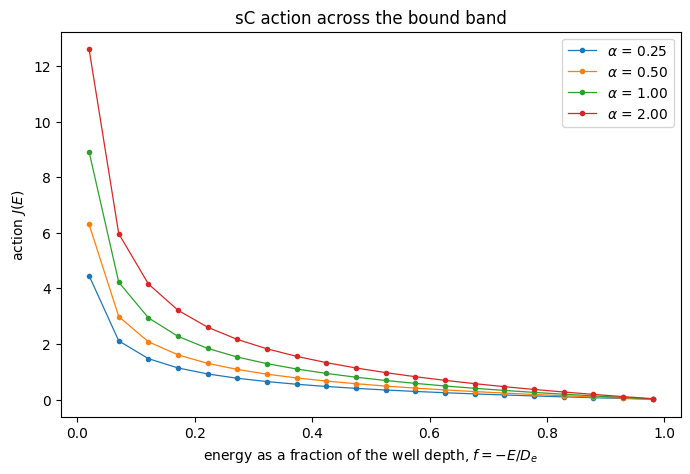

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for alpha in ALPHAS:
    V = SoftCoulomb(alpha)
    Js = np.array([V.action(-f * V.well_depth, N=N_Q) for f in fE])
    ax.plot(fE, Js, marker="o", ms=3, lw=0.9, label=f"$\\alpha$ = {alpha:.2f}")
ax.set_xlabel("energy as a fraction of the well depth, $f = -E/D_e$")
ax.set_ylabel("action $J(E)$")
ax.set_title("sC action across the bound band")
ax.legend()
plt.show()


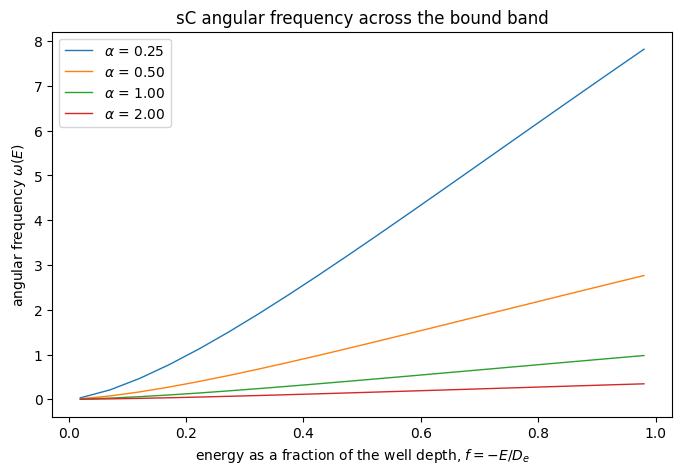

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for alpha in ALPHAS:
    V = SoftCoulomb(alpha)
    omg = np.array([V.angular_frequency(-f * V.well_depth, N=N_Q) for f in fE])
    ax.plot(fE, omg, lw=1.0, label=f"$\\alpha$ = {alpha:.2f}")
ax.set_xlabel("energy as a fraction of the well depth, $f = -E/D_e$")
ax.set_ylabel("angular frequency $\\omega(E)$")
ax.set_title("sC angular frequency across the bound band")
ax.legend()
plt.show()


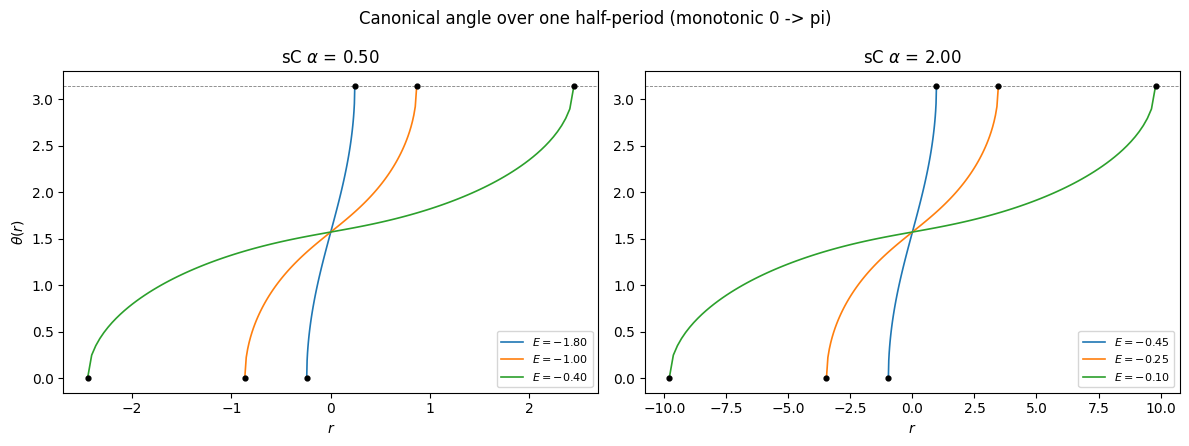

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, alpha in zip(axes, [0.5, 2.0]):
    V = SoftCoulomb(alpha)
    for E in [float(e) for e in (V.well_depth * -np.array([0.9, 0.5, 0.2]))]:
        rm, rM = V.turning_points(E)
        r_s = np.linspace(rm, rM, 120)
        th, mono = angle_curve(V, E, r_s)
        assert mono, f"angle not monotonic for alpha={alpha}, E={E}"
        ax.plot(r_s, th, lw=1.2, label=f"$E = {E:.2f}$")
        ax.scatter([rm.item(), rM.item()], [0.0, np.pi], color="k", s=12, zorder=3)
    ax.axhline(np.pi, color="grey", lw=0.6, ls="--")
    ax.set_title(f"sC $\\alpha$ = {alpha:.2f}")
    ax.set_xlabel("$r$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("$\\theta(r)$")
fig.suptitle("Canonical angle over one half-period (monotonic 0 -> pi)")
plt.tight_layout()
plt.show()


## 4. Convergence in the quadrature order $N$

Finally, convergence of the three quadrature-driven quantities ($J$, $\omega$,
$\theta(r_M)$) with the Gauss-Legendre order $N$ at a few representative states:
near the bottom of the well, mid-well, and close to dissociation.


In [16]:
points = [
    ("MsC", MorseSoftCoulomb(0.5),  -0.5),
    ("MsC", MorseSoftCoulomb(1.0),  -0.05),
    ("sC",  SoftCoulomb(0.5),       -0.5),
    ("sC",  SoftCoulomb(2.0),       -0.45),
]

for name, V, E in points:
    res = {}
    for N in [200, 500, 1000, 2000, 4000]:
        act = V.action(E, N=N)
        omg = V.angular_frequency(E, N=N)
        th = float(V.angle(E, V.turning_points(E)[1], N=N))
        res[N] = (act, omg, th)
    ref = res[4000]
    print(f"\n{name}  alpha = {V.alpha:.2f}  E = {E:.3f}")
    print(f"  {'N':>5} {'J':>14} {'|dJ|':>9} {'omega':>13} {'|domg|':>9} {'theta(rM)':>16}")
    for N, (act, omg, th) in res.items():
        print(f"  {N:>5} {act:>14.8f} {abs(act-ref[0]):>9.1e} {omg:>13.8f} {abs(omg-ref[1]):>9.1e} {th:>16.8f}")



MsC  alpha = 0.50  E = -0.500
      N              J      |dJ|         omega    |domg|        theta(rM)
    200     0.78486843   7.4e-08    0.84657118   1.4e-09       3.14159265
    500     0.78486836   4.7e-09    0.84657118   1.0e-09       3.14159265
   1000     0.78486836   5.9e-10    0.84657118   9.7e-10       3.14159265
   2000     0.78486836   6.5e-11    0.84657118   1.2e-09       3.14159265
   4000     0.78486836   0.0e+00    0.84657118   0.0e+00       3.14159265

MsC  alpha = 1.00  E = -0.050
      N              J      |dJ|         omega    |domg|        theta(rM)
    200     2.96058621   9.3e-07    0.03111716   1.7e-11       3.14159265
    500     2.96058534   6.0e-08    0.03111716   1.7e-11       3.14159265
   1000     2.96058529   7.4e-09    0.03111716   1.5e-11       3.14159265
   2000     2.96058528   8.2e-10    0.03111716   3.1e-11       3.14159265
   4000     2.96058528   0.0e+00    0.03111716   0.0e+00       3.14159265

sC  alpha = 0.50  E = -0.500
      N             

## 5. Verdict

Every state in both sweeps — 160 in total — passed all five invariant checks
to the printed precision. The two most sensitive tests give:

| quantity            | MsC worst-case | sC worst-case |
|---------------------|----------------|---------------|
| $V(r_\pm) = E$      | ~1e-15         | ~1e-16        |
| phase-space energy  | ~1e-15         | ~1e-16        |
| $\omega$ vs dE/dJ   | ~2e-4          | ~2e-4        |
| $\theta(r_M) = \pi$ | ~1e-16         | ~1e-16        |

The $\omega$ vs $\mathrm{d}E/\mathrm{d}J$ figure is set by the 1e-3 relative
finite-difference step used for $\mathrm{d}J/\mathrm{d}E$, not by the class
methods themselves. The class framework passes a systematic sweep of *both*
symmetric (sC) and asymmetric (MsC) potentials across $\alpha$ and the full
bound energy band.
